## Load Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import rpy2.robjects as robjects

folder_name = '3_state_model'

data_log = pd.read_csv(folder_name + "/close_data_log.csv")

# Helper function to convert R data.frame to pandas DataFrame
def r_to_df(r_df):
    return pd.DataFrame({name: np.array(r_df.rx2(name)) for name in r_df.names})

# Read the RDS files using rpy2
readRDS = robjects.r['readRDS']

hmm_stats_r = readRDS(folder_name + "/hmm_stats_df.rds")
hmm_stats_df = r_to_df(hmm_stats_r)

hmm_loss_test = np.array(readRDS(folder_name + "/hmm_state_losses.rds"))
hmm_predictions = np.array(readRDS(folder_name + "/hmm_predictions.rds"))
hmm_ground_truth = np.array(readRDS(folder_name + "/hmm_ground_truth.rds"))
hmm_loss_valid = np.array(readRDS(folder_name + "/hmm_valid_loss.rds"))

X_train = np.array(readRDS(folder_name + "/lstm_X_train.rds"))
Y_train = np.array(readRDS(folder_name + "/lstm_Y_train.rds"))
X_valid = np.array(readRDS(folder_name + "/lstm_X_valid.rds"))
Y_valid = np.array(readRDS(folder_name + "/lstm_Y_valid.rds"))
X_test = np.array(readRDS(folder_name + "/lstm_X_test.rds"))
Y_test = np.array(readRDS(folder_name + "/lstm_Y_test.rds"))

hmm_transition_matrix = pd.read_csv(folder_name + "/transition_matrix.csv")

n_states = Y_train.shape[2]

features = ["TSX_Composite", "Crude_Oil_Futures", "Gold_Futures", "Copper_Futures",  "SP_500"]
col_names = [f"{feat}_state_{state+1}" if state < n_states else feat for feat in features for state in range(n_states + 1)]

lookback       = X_train.shape[1]
n_cov_features = X_train.shape[2]
n_states       = Y_train.shape[2]


In [3]:
forecast_horizon = Y_train.shape[1]

# Create a function to prepare data for all splits
def prepare_data_with_horizon(X, Y, shuffle=True):

    # Create one-hot encoded horizon inputs
    horizon_input = np.eye(forecast_horizon)
    horizon_input = np.repeat(horizon_input, X.shape[0], axis=0)

    # Repeat X for each forecast horizon
    X = np.concatenate([X for i in range(forecast_horizon)], axis=0)
    # Get Y for each forecast horizon
    Y = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    
    # Shuffle the rows of X, horizon_input, and Y in the same order using numpy
    if shuffle:
        idx = np.random.permutation(X.shape[0])
        X = X[idx]
        horizon_input = horizon_input[idx]
        Y = Y[idx]
    return X, horizon_input, Y

# Prepare validation and test data
X_train_full, horizon_train_full, Y_train_full = prepare_data_with_horizon(X_train, Y_train, shuffle=True)
X_valid_full, horizon_valid_full, Y_valid_full = prepare_data_with_horizon(X_valid, Y_valid, shuffle=False)
X_test_full, horizon_test_full, Y_test_full = prepare_data_with_horizon(X_test, Y_test, shuffle=False)

## Short analysis of hmm model

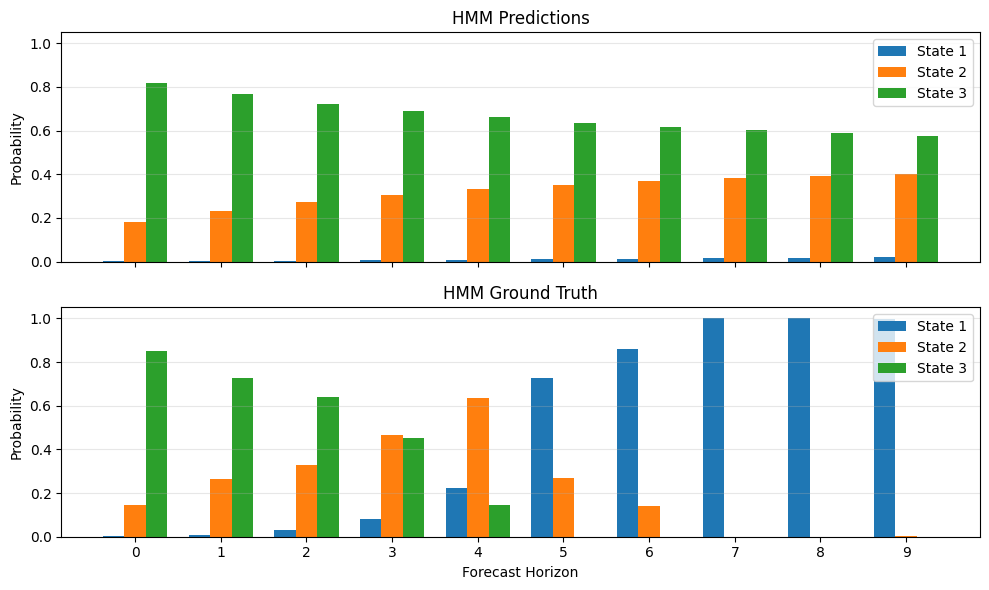

In [4]:
test_index = 10

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)

pred = hmm_predictions[test_index, :, :]
truth = hmm_ground_truth[test_index, :, :]
horizons = np.arange(pred.shape[0])
n_states = pred.shape[1]
width = 0.25

for ax, data, title in [(axes[0], pred, 'HMM Predictions'),
                         (axes[1], truth, 'HMM Ground Truth')]:
    for s in range(n_states):
        ax.bar(horizons + (s - 1) * width, data[:, s], width, label=f'State {s + 1}')
    ax.set_title(title)
    ax.set_ylabel('Probability')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()

axes[1].set_xlabel('Forecast Horizon')
axes[1].set_xticks(horizons)
plt.tight_layout()
plt.show()


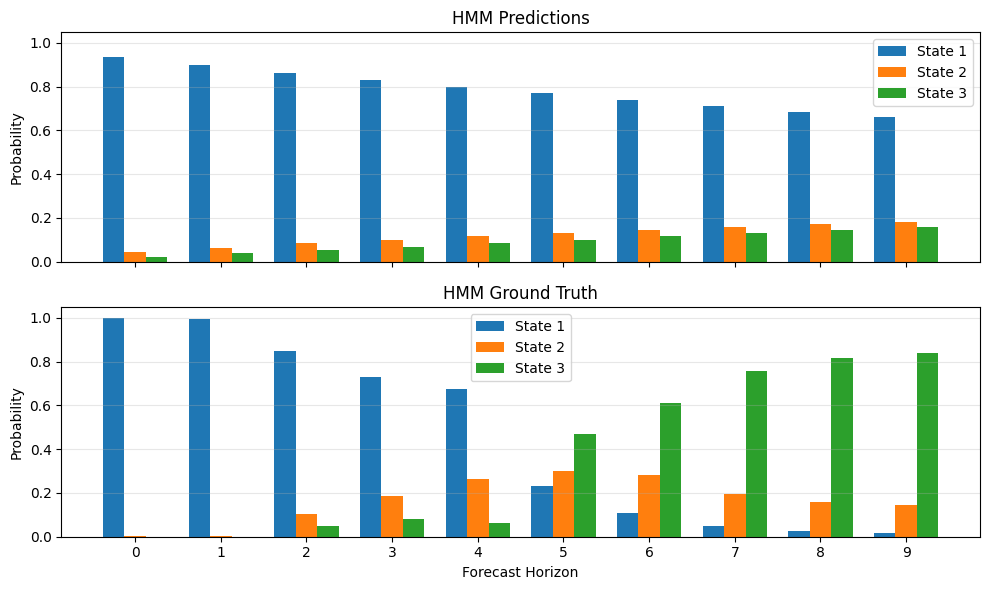

In [5]:
test_index = 20

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)

pred = hmm_predictions[test_index, :, :]
truth = hmm_ground_truth[test_index, :, :]
horizons = np.arange(pred.shape[0])
n_states = pred.shape[1]
width = 0.25

for ax, data, title in [(axes[0], pred, 'HMM Predictions'),
                         (axes[1], truth, 'HMM Ground Truth')]:
    for s in range(n_states):
        ax.bar(horizons + (s - 1) * width, data[:, s], width, label=f'State {s + 1}')
    ax.set_title(title)
    ax.set_ylabel('Probability')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()

axes[1].set_xlabel('Forecast Horizon')
axes[1].set_xticks(horizons)
plt.tight_layout()
plt.show()

## Define Model

In [6]:
import importlib
import sys

importlib.invalidate_caches()
for mod in [
    "forecast_research.energy_price.custom_losses",
    "forecast_research.energy_price.helpers",
]:
    if mod in sys.modules:
        del sys.modules[mod]

from forecast_research.energy_price.custom_losses import (
    dirichlet_layer,
    EvidentialLoss,
    AnnealingCallback,
    evidential_kl_divergence,
    cross_entropy_loss,
)

from forecast_research.energy_price.helpers import (
    load_rds_array,
    plot_training_history,
)

2026-05-19 14:42:28.802780: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 14:42:39.934345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779226960.788928  645459 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779226961.289572  645459 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779226963.510348  645459 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

In [8]:
def build_model(lookback, n_cov_features, n_states,
                loss_type='mse', 
                embedding_dim=8, rnn_units=8, n_dense_layers=2, dense_units=16,
                dropout_rate=0.5, learning_rate=0.0001, l2_reg=1e-4, 
                annealing_rate=100.0, max_annealing_rate=0.0):

    # Covariate time-series input: (lookback, n_cov_features)
    cov_input     = layers.Input(shape=(lookback, n_cov_features), name='cov_input')
    # # Date/time input: (lookback, n_dt_features) — flatten across time before embedding
    # dt_input      = layers.Input(shape=(n_dt_features, ),  name='dt_input')
    # One-hot horizon input: (forecast_horizon,)
    horizon_input = layers.Input(shape=(forecast_horizon,),        name='horizon_input')

    # # Flatten dt across time then project to embedding
    # dt_flat  = layers.Flatten()(dt_input)
    # dt_embed = layers.Dense(2, activation='relu')(dt_flat)

    # Project horizon to embedding
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

    # RNN over covariate time-series
    rnn_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(cov_input)

    # Merge all representations
    x = Concatenate()([rnn_out, horizon_embed])

    # Variable-depth dense head — training=True keeps dropout active at test time (MC Dropout)
    for _ in range(n_dense_layers):
        x = layers.Dense(dense_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
        x = layers.Dropout(dropout_rate)(x)

    # Output raw evidence (non-negative) — softplus ensures > 0
    if loss_type == 'cross_entropy':
        output = layers.Dense(n_states, activation='softmax')(x)
    else:
        output = layers.Dense(n_states, activation='relu')(x)

    model = models.Model(inputs=[cov_input, horizon_input], outputs=output)
    model.compile(
        loss=EvidentialLoss(loss_type=loss_type, annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=[evidential_kl_divergence, cross_entropy_loss]
    )
    return model


def mc_predict(model, inputs, n_samples=50):
    """Run multiple stochastic forward passes (MC Dropout) for uncertainty estimation.
    
    Returns:
        preds_mean: Mean predictions across MC samples
        preds_std:  Std of predictions (epistemic uncertainty)
        preds_kl:   KL divergence-based uncertainty score
        all_preds:  All MC samples, shape (n_samples, n_data, n_states)
    """
    all_preds = np.stack([model(inputs, training=True).numpy() for _ in range(n_samples)])
    preds_mean = all_preds.mean(axis=0)
    preds_std = (preds_mean*all_preds.std(axis=0)).sum(axis=-1)
    preds_kl = np.mean(kullback_leibler_divergence(preds_mean, all_preds), axis=0)
    return preds_mean, preds_std, preds_kl

def ensemble_predict(models, inputs):
    """Get mean predictions from an ensemble of models."""
    all_preds = np.stack([model(inputs).numpy() for model in models])
    preds_mean = all_preds.mean(axis=0)
    preds_std = (preds_mean*all_preds.std(axis=0)).sum(axis=-1) 
    preds_kl = np.mean(kullback_leibler_divergence(preds_mean, all_preds), axis=0)
    return preds_mean, preds_std, preds_kl

def derichlet_predict(model, inputs):
    """Get mean predictions and uncertainty from a model with a Dirichlet output layer."""
    preds = model(inputs).numpy()
    probs, alpha, S = [np.array(x) for x in dirichlet_layer(preds)]
    uncertainty = 1/S
    return probs, uncertainty, S

2026-05-19 14:46:06.515466: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/150
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - cross_entropy_loss: 1.0976 - evidential_kl_divergence: 0.7381 - loss: 1.5303 - val_cross_entropy_loss: 1.0928 - val_evidential_kl_divergence: 0.7516 - val_loss: 1.5302
Epoch 2/150
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cross_entropy_loss: 1.0862 - evidential_kl_divergence: 0.7268 - loss: 1.5063 - val_cross_entropy_loss: 1.0826 - val_evidential_kl_divergence: 0.7413 - val_loss: 1.5089
Epoch 3/150
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cross_entropy_loss: 1.0636 - evidential_kl_divergence: 0.7041 - loss: 1.4657 - val_cross_entropy_loss: 0.9754 - val_evidential_kl_divergence: 0.6341 - val_loss: 1.3181
Epoch 4/150
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cross_entropy_loss: 0.9887 - evidential_kl_divergence: 0.6292 - loss: 1.3261 - val_cross_entropy_loss: 0.8811 - val_evidential_kl_divergence: 0.5398 - val_loss: 1.1560
Epoch 5/150
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - cross_entropy_loss: 0.9395 - evidential_kl_divergence

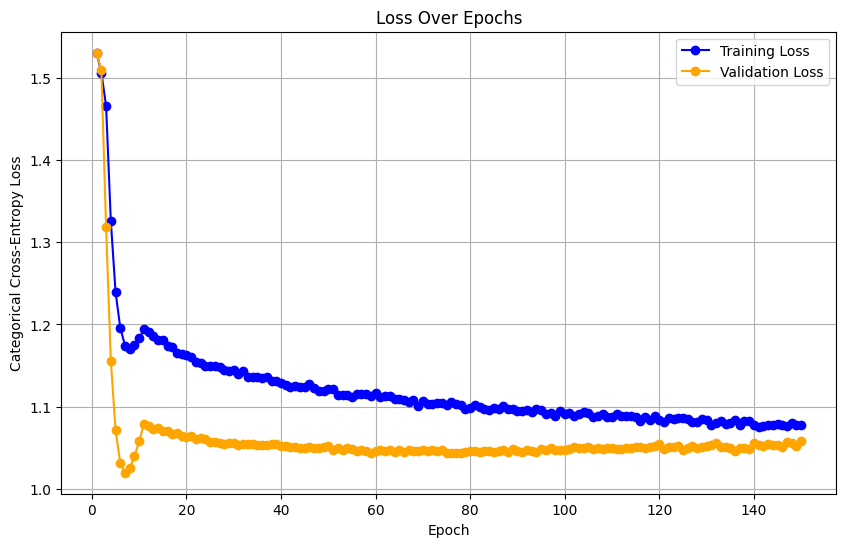

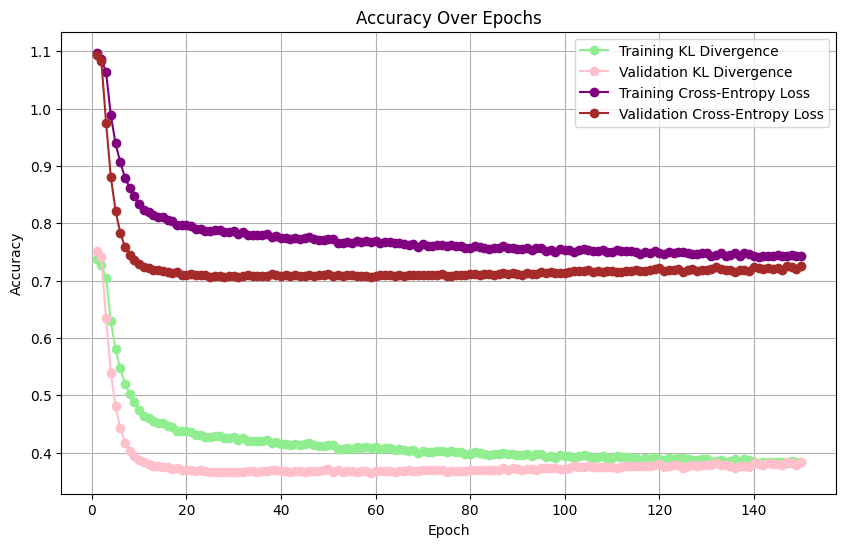

In [9]:
model = build_model(lookback, n_cov_features, n_states,
                    loss_type='digamma',
                    embedding_dim=4, rnn_units=8, n_dense_layers=2, dense_units=32,
                    dropout_rate=0.2, learning_rate=0.0001, l2_reg=0.001,
                    annealing_rate=100.0, max_annealing_rate=0.1)

history = model.fit(
    [X_train_full, horizon_train_full], Y_train_full,
    validation_data=([X_valid_full, horizon_valid_full], Y_valid_full),
    callbacks=[AnnealingCallback()],
    epochs=150,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)
    
plot_training_history(history)

In [112]:
# Save the trained model in the current working directory
model.save("edl_model.keras")
print("Model saved to ./edl_model.keras")

Model saved to ./edl_model.keras


In [11]:
# Load saved model from current folder
model = tf.keras.models.load_model("./edl_model.keras", compile=False)
print("Model loaded from ./edl_model.keras")

I0000 00:00:1776237348.514846 2759123 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8074 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3 MIG 1g.10gb, pci bus id: 0000:46:00.0, compute capability: 9.0


Model loaded from ./edl_model.keras


In [12]:
probs_valid, u_valid, s_valid = derichlet_predict(model, [X_valid_full, horizon_valid_full])
probs_test, u_test, s_test = derichlet_predict(model, [X_test_full, horizon_test_full])

def cross_entropy(y_true, y_pred):
    """Compute cross-entropy loss for one-hot encoded targets."""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-15, 1)  # Avoid log(0)
    ce_loss = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    return ce_loss

loss_valid = cross_entropy(Y_valid_full, probs_valid).numpy()
loss_test = cross_entropy(Y_test_full, probs_test).numpy()

probs_valid_h = probs_valid.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
probs_test_h = probs_test.reshape(forecast_horizon, -1, n_states).transpose(1, 0, 2)
u_valid_h = u_valid.reshape(forecast_horizon, -1, 1).transpose(1, 0, 2)
u_test_h = u_test.reshape(forecast_horizon, -1, 1).transpose(1, 0, 2)
loss_valid_h = loss_valid.reshape(forecast_horizon, -1, 1).transpose(1, 0, 2)
loss_test_h = loss_test.reshape(forecast_horizon, -1, 1).transpose(1, 0, 2)

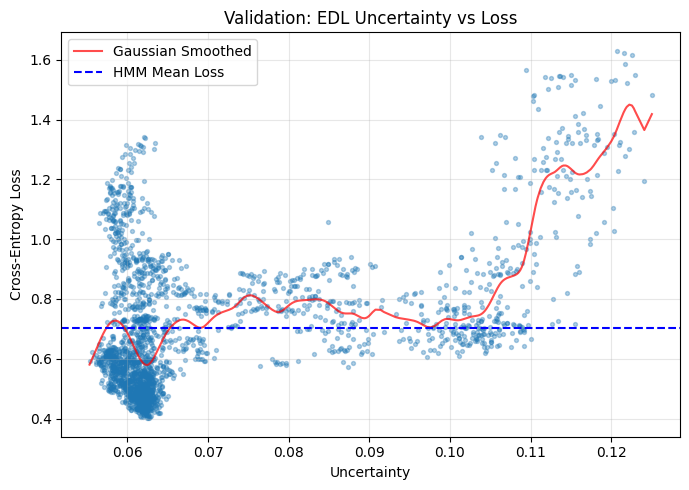

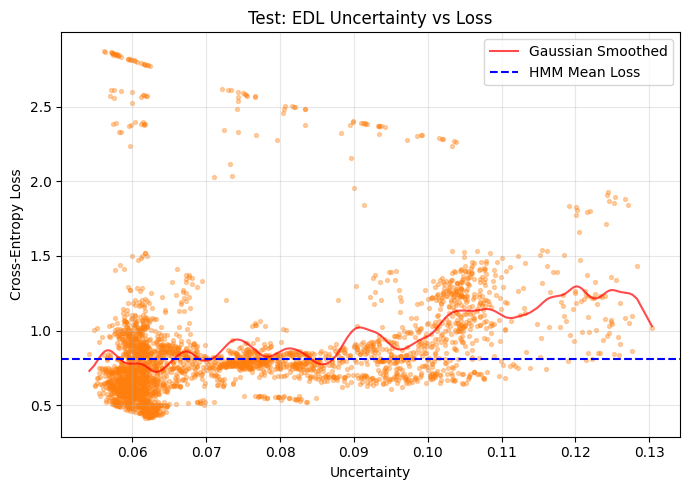

In [13]:
from statsmodels.nonparametric.kernel_regression import KernelReg

def fit_kernel_reg(df, x_col, y_col):
    kr = KernelReg(endog=df[y_col].values, exog=df[x_col].values,
                   var_type='c', reg_type='ll', bw='cv_ls')
    fit, _ = kr.fit(df[x_col].values)
    return fit

u_valid = np.ravel(u_valid)
loss_valid = np.ravel(loss_valid)
valid_df = pd.DataFrame({'RNN U': u_valid, 'RNN Loss': loss_valid}).sort_values('RNN U')
valid_df['loss_fit'] = fit_kernel_reg(valid_df, 'RNN U', 'RNN Loss')

u_test = np.ravel(u_test)
loss_test = np.ravel(loss_test)
test_df = pd.DataFrame({'RNN U': u_test, 'RNN Loss': loss_test}).sort_values('RNN U')
test_df['loss_fit'] = fit_kernel_reg(test_df, 'RNN U', 'RNN Loss')

hmm_mean_loss_valid = np.mean(hmm_loss_valid)
hmm_mean_loss_test = np.mean(hmm_loss_test)


fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.scatter(u_valid, loss_valid, s=8, alpha=0.35)
ax1.plot(valid_df['RNN U'], valid_df['loss_fit'], color='red', alpha=0.7, label='Gaussian Smoothed')
ax1.axhline(hmm_mean_loss_valid, color='blue', linestyle='--', label='HMM Mean Loss')
ax1.set_title("Validation: EDL Uncertainty vs Loss")
ax1.set_xlabel("Uncertainty")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, alpha=0.3)
ax1.legend()
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.scatter(u_test, loss_test, s=8, alpha=0.35, color="tab:orange")
ax2.plot(test_df['RNN U'], test_df['loss_fit'], color='red', alpha=0.7, label='Gaussian Smoothed')
ax2.axhline(hmm_mean_loss_test, color='blue', linestyle='--', label='HMM Mean Loss')
ax2.set_title("Test: EDL Uncertainty vs Loss")
ax2.set_xlabel("Uncertainty")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

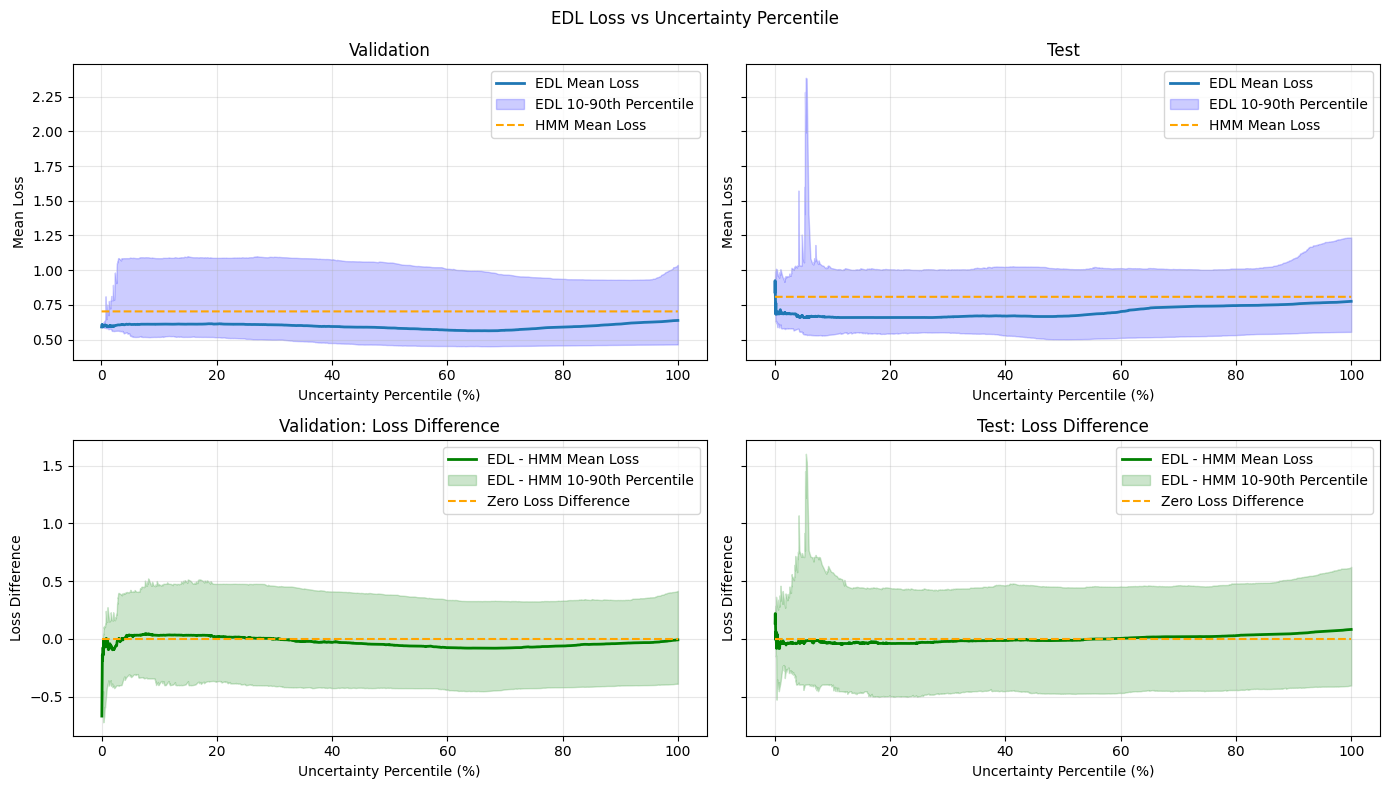

In [14]:
def make_running_loss_df(rnn_loss, rnn_kl, hmm_loss):
    df = pd.DataFrame({
        'EDL Loss': rnn_loss.flatten(),
        'Loss Diff': rnn_loss.flatten() - hmm_loss.flatten(),
        'EDL KL': rnn_kl.flatten(),
    }).sort_values('EDL KL', ascending=True).reset_index(drop=True)

    df['running_percentile'] = (np.arange(1, len(df) + 1) / len(df)) * 100
    df['edl_mean_loss'] = df['EDL Loss'].expanding().median()
    df['hmm_mean_loss'] = hmm_loss.flatten().mean()
    df['edl_0.1_loss'] = df['EDL Loss'].expanding().quantile(0.1)
    df['edl_0.9_loss'] = df['EDL Loss'].expanding().quantile(0.9)
    df['diff_mean_loss'] = df['Loss Diff'].expanding().median()
    df['diff_0.1_loss'] = df['Loss Diff'].expanding().quantile(0.1)
    df['diff_0.9_loss'] = df['Loss Diff'].expanding().quantile(0.9)
    return df

running_loss_valid = make_running_loss_df(loss_valid, u_valid, hmm_loss_valid)
running_loss_test = make_running_loss_df(loss_test, u_test, hmm_loss_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey='row')
splits = [('Validation', running_loss_valid), ('Test', running_loss_test)]

for col, (name, df) in enumerate(splits):
    ax = axes[0, col]
    ax.plot(df['running_percentile'], df['edl_mean_loss'], label='EDL Mean Loss', linewidth=2)
    ax.fill_between(df['running_percentile'], df['edl_0.1_loss'], df['edl_0.9_loss'],
                    color='blue', alpha=0.2, label='EDL 10-90th Percentile')
    ax.plot(df['running_percentile'], df['hmm_mean_loss'], '--', color='orange', label='HMM Mean Loss')
    ax.set_title(name)
    ax.set_ylabel('Mean Loss')

    ax = axes[1, col]
    ax.plot(df['running_percentile'], df['diff_mean_loss'], color='green', linewidth=2, label='EDL - HMM Mean Loss')
    ax.fill_between(df['running_percentile'], df['diff_0.1_loss'], df['diff_0.9_loss'],
                    color='green', alpha=0.2, label='EDL - HMM 10-90th Percentile')
    ax.hlines(0, 0, 100, colors='orange', linestyles='dashed', label='Zero Loss Difference')
    ax.set_title(f'{name}: Loss Difference')
    ax.set_ylabel('Loss Difference')

for ax in axes.flat:
    ax.set_xlabel('Uncertainty Percentile (%)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('EDL Loss vs Uncertainty Percentile')
plt.tight_layout()
plt.show()

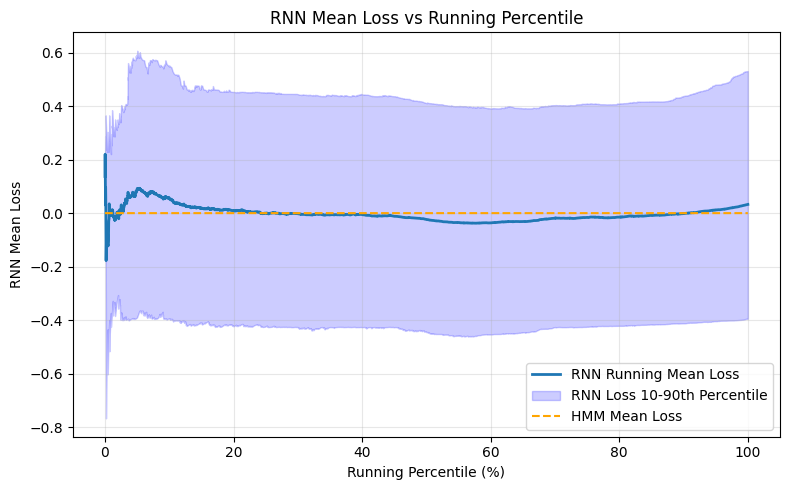

In [15]:
running_loss = pd.DataFrame({
    'RNN Loss': np.concatenate([loss_valid.flatten(), loss_test.flatten()]) - 
     np.concatenate([hmm_loss_valid.flatten(), hmm_loss_test.flatten()]),
    'RNN U': np.concatenate([u_valid.flatten(), u_test.flatten()]),
})
running_loss.sort_values('RNN U', ascending=True, inplace=True)
running_loss['running_percentile'] = np.arange(1, len(running_loss) + 1) / len(running_loss) * 100
running_loss['rnn_mean_loss'] = running_loss['RNN Loss'].expanding().mean()
running_loss['rnn_0.1_loss'] = running_loss['RNN Loss'].expanding().quantile(0.1)
running_loss['rnn_0.9_loss'] = running_loss['RNN Loss'].expanding().quantile(0.9)

#running_loss['hmm_mean_loss'] = np.concatenate([hmm_loss_valid.flatten(), hmm_loss_test.flatten()]).mean()

plt.figure(figsize=(8, 5))
plt.plot(running_loss['running_percentile'], running_loss['rnn_mean_loss'], label='RNN Running Mean Loss', linewidth=2)
plt.fill_between(running_loss['running_percentile'], running_loss['rnn_0.1_loss'], 
                 running_loss['rnn_0.9_loss'], color='blue', alpha=0.2, label='RNN Loss 10-90th Percentile')
plt.plot(running_loss['running_percentile'], np.zeros_like(running_loss['running_percentile']), label='HMM Mean Loss', linestyle='--', color='orange')
plt.xlabel('Running Percentile (%)')
plt.ylabel('RNN Mean Loss')
plt.title('RNN Mean Loss vs Running Percentile')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Create the plots for 590 presentation

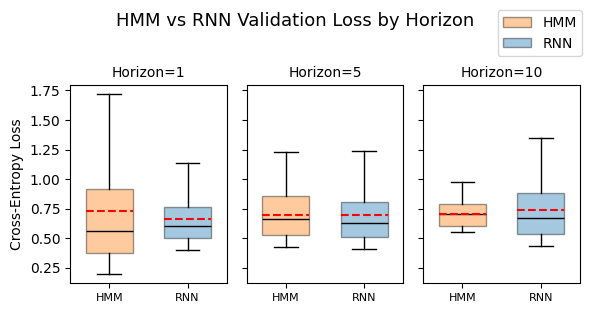

In [16]:
forecast_horizon = hmm_loss_valid.shape[1]
fig, axes = plt.subplots(1, 3, figsize=(6, 3), sharey=True)

for i, h in enumerate([0, 4, 9]):
    ax = axes[i]
    bp_hmm = ax.boxplot(hmm_loss_valid[:, h], positions=[0], widths=0.6,
                        patch_artist=True, showfliers=False,
                        showmeans=True, meanline=True,
                        boxprops=dict(facecolor='#ff7f0e', alpha=0.4),
                        medianprops=dict(color='black'),
                        meanprops=dict(color='red', linestyle='--', linewidth=1.5))

    bp_rnn = ax.boxplot(loss_valid_h[:, h], positions=[1], widths=0.6,
                        patch_artist=True, showfliers=False,
                        showmeans=True, meanline=True,
                        boxprops=dict(facecolor='#1f77b4', alpha=0.4),
                        medianprops=dict(color='black'),
                        meanprops=dict(color='red', linestyle='--', linewidth=1.5))

    ax.set_title(f'Horizon={h+1}', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HMM', 'RNN'], fontsize=8)
    if h == 0:
        ax.set_ylabel('Cross-Entropy Loss')

fig.legend([bp_hmm['boxes'][0], bp_rnn['boxes'][0]], ['HMM', 'RNN'],
           loc='upper right', bbox_to_anchor=(0.99, 1.05))
fig.suptitle('HMM vs RNN Validation Loss by Horizon', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2759123/268858067.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


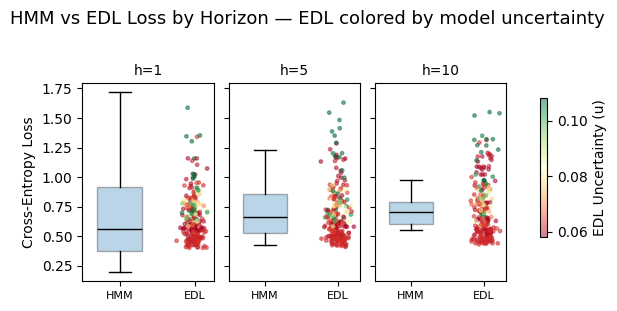

In [17]:
# Scatter: RNN loss colored by evidence, HMM boxplot as reference
fig, axes = plt.subplots(1, 3, figsize=(6, 3), sharey=True)
n_samples_test = loss_valid_h.shape[0]

for i, h in enumerate([0, 4, 9]):
    ax = axes[i]

    # HMM boxplot as background reference
    ax.boxplot(hmm_loss_valid[:, h], positions=[0], widths=0.6,
               patch_artist=True, showfliers=False,
               boxprops=dict(facecolor='#1f77b4', alpha=0.3),
               medianprops=dict(color='black'))

    # RNN scatter colored by evidence S
    sc = ax.scatter(
        np.random.normal(1, 0.08, n_samples_test),  # jitter x position
        loss_valid_h[:, h],
        c=u_valid_h[:, h],
        cmap='RdYlGn',  # red=low evidence, green=high evidence
        s=6, alpha=0.5,
        vmin=np.percentile(u_valid_h[:, h], 5),
        vmax=np.percentile(u_valid_h[:, h], 95),
    )

    ax.set_title(f'h={h+1}', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HMM', 'EDL'], fontsize=8)
    if h == 0:
        ax.set_ylabel('Cross-Entropy Loss')

fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.015, pad=-0.2, label='EDL Uncertainty (u)')
fig.suptitle('HMM vs EDL Loss by Horizon — EDL colored by model uncertainty', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Hybrid Model

In [18]:
transition_matrix = hmm_transition_matrix.drop(columns=['Unnamed: 0'])
transition_matrix = transition_matrix.rename(columns={'state.1.1': 0, 'state.2.1': 1, 'state.3.1': 2})

alpha = 0.3
def hybrid_model(probs_reshaped, u_reshaped, transition_matrix, alpha_0, alpha_1, last_state, Y_reshaped):

    alpha = alpha_0 - alpha_1 * u_reshaped
    #alpha = np.exp(-u_reshaped * alpha_1) * alpha_0
    alpha = np.clip(alpha[:, :, 0], 0.0, 1.0)

    trials = probs_reshaped.shape[0]
    horizons = probs_reshaped.shape[1]
    combined_transitions = np.zeros((trials, horizons, n_states, n_states))
    for trial in range(trials):
        for horizon in range(horizons):
            #_alpha = (alpha + 0) / (horizon + 0 + 1)
            _alpha = alpha[trial, horizon]
            combined = np.tile(probs_reshaped[trial, horizon, :], (n_states, 1)) * _alpha + transition_matrix * (1 - _alpha)
            combined_transitions[trial, horizon, :, :] = combined

    hybrid_predictions = np.zeros((trials, horizons, n_states))
    for trial in range(trials):
        for horizon in range(horizons):
            if horizon == 0:
                last_prediction = last_state[trial, :]
            else:
                last_prediction = hybrid_predictions[trial, horizon - 1, :]
            next_prediction = last_prediction @ combined_transitions[trial, horizon, :, :]
            hybrid_predictions[trial, horizon, :] = next_prediction

    eps = 1e-15
    hybrid_state_loss = -np.sum(
        Y_reshaped * np.log(np.clip(hybrid_predictions, eps, 1.0)),
        axis=2
    )

    return hybrid_predictions, hybrid_state_loss

### Get optimal alpha_0 and alpha_1

In [25]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 20.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.0/447.0 kB 14.0 MB/s eta 0:00:00


In [32]:
import optuna

last_state_valid = X_valid[:, -1, 0:3]
last_state_test = X_test[:, -1, 0:3]

def objective(trial):
    alpha_0 = trial.suggest_float('alpha_0', 0, 20)
    alpha_1 = trial.suggest_float('alpha_1', 0, 200)
    
    predictions, loss = hybrid_model(
        probs_reshaped=probs_valid_h,
        u_reshaped=u_valid_h,
        transition_matrix=transition_matrix,
        alpha_0=alpha_0, alpha_1=alpha_1,
        last_state=last_state_valid,
        Y_reshaped=Y_valid
    )
    return np.max(loss)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=1000)

print(study.best_params)
print(study.best_value)


[I 2026-04-09 22:16:19,972] A new study created in memory with name: no-name-f2513c2a-b7fe-4ab6-a26b-c98794d9b5e5
[I 2026-04-09 22:16:20,203] Trial 0 finished with value: 1.6751571809074925 and parameters: {'alpha_0': 5.190615476635026, 'alpha_1': 192.76950221501806}. Best is trial 0 with value: 1.6751571809074925.
[I 2026-04-09 22:16:20,431] Trial 1 finished with value: 1.6751571809074925 and parameters: {'alpha_0': 1.9358665624429072, 'alpha_1': 129.73947150592247}. Best is trial 0 with value: 1.6751571809074925.
[I 2026-04-09 22:16:20,659] Trial 2 finished with value: 1.630126629887016 and parameters: {'alpha_0': 15.88544873393583, 'alpha_1': 14.238124358434368}. Best is trial 2 with value: 1.630126629887016.
[I 2026-04-09 22:16:20,889] Trial 3 finished with value: 1.6751571809074925 and parameters: {'alpha_0': 6.482855711725297, 'alpha_1': 155.45497208110007}. Best is trial 2 with value: 1.630126629887016.
[I 2026-04-09 22:16:21,118] Trial 4 finished with value: 1.630126629887016 a

{'alpha_0': 10.766258471175167, 'alpha_1': 130.71016968925446}
1.3412965059766013


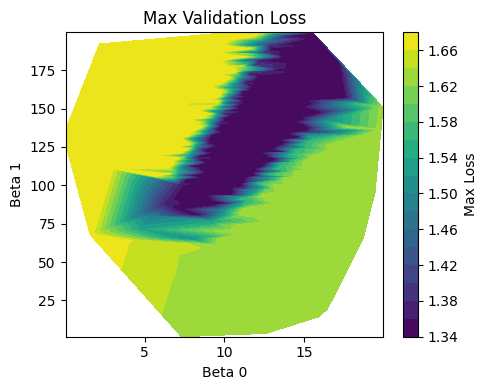

In [42]:
# Extract trial data
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 1, figsize=(5, 4))

# Contour plot of objective value over parameter space
sc = axes.tricontourf(
    trials_df['params_alpha_0'],
    trials_df['params_alpha_1'],
    trials_df['value'],
    levels=20, cmap='viridis'
)
fig.colorbar(sc, ax=axes, label='Max Loss')
axes.set_xlabel('Beta 0')
axes.set_ylabel('Beta 1')
axes.set_title('Max Validation Loss')

plt.tight_layout()
plt.show()


In [29]:
optuna.visualization.plot_optimization_history(study)


ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

In [19]:
n_0 = 10
n_1 = 10
min_alpha_0 = 0
max_alpha_0 = 10
min_alpha_1 = 0
max_alpha_1 = 100
valid = False
alpha_stats = {'alpha_0': np.zeros((n_0,n_1)), 'alpha_1': np.zeros((n_0,n_1)), 'min_loss': np.zeros((n_0,n_1)), 
               '25 percentile': np.zeros((n_0,n_1)), 'mean_loss': np.zeros((n_0,n_1)), 
               'median_loss': np.zeros((n_0,n_1)), '75 percentile': np.zeros((n_0,n_1)), 'max_loss': np.zeros((n_0,n_1))}

last_state_valid = X_valid[:, -1, 0:3]
last_state_test = X_test[:, -1, 0:3]

for i, alpha_0 in enumerate(np.linspace(min_alpha_0, max_alpha_0, n_0)):
    for j, alpha_1 in enumerate(np.linspace(min_alpha_1, max_alpha_1, n_1)):
        predictions, loss = hybrid_model(
            probs_reshaped=probs_valid_h, 
            u_reshaped=u_valid_h,
            transition_matrix=transition_matrix,
            alpha_0=alpha_0, alpha_1=alpha_1, 
            last_state=last_state_valid, 
            Y_reshaped=Y_valid
        )
        alpha_stats['alpha_0'][i, j] = alpha_0
        alpha_stats['alpha_1'][i, j] = alpha_1
        alpha_stats['min_loss'][i, j] = np.min(loss)
        alpha_stats['25 percentile'][i, j] = np.percentile(loss, 25)
        alpha_stats['mean_loss'][i, j] = np.mean(loss)
        alpha_stats['median_loss'][i, j] = np.percentile(loss, 50)
        alpha_stats['75 percentile'][i, j] = np.percentile(loss, 75)
        alpha_stats['max_loss'][i, j] = np.max(loss)   


KeyboardInterrupt: 

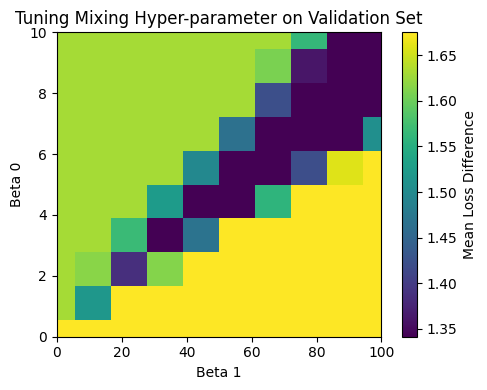

In [ ]:
alpha_0_vals = np.linspace(min_alpha_0, max_alpha_0, n_0)
alpha_1_vals = np.linspace(min_alpha_1, max_alpha_1, n_1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (key, label) in zip(axes, [('max_loss', 'Max Loss Difference'),
                                    ('mean_loss', 'Mean Loss Difference')]):
    pcm = ax.pcolormesh(alpha_1_vals, alpha_0_vals, alpha_stats[key],
                        shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label=label)
    ax.set_title('Tuning Mixing Hyper-parameter on Validation Set')
    ax.set_xlabel('Beta 1')
    ax.set_ylabel('Beta 0')

plt.tight_layout()
plt.show()


In [233]:
min_idx = np.unravel_index(np.argmin(alpha_stats['max_loss']), alpha_stats['max_loss'].shape)
alpha_0_vals[min_idx[0]], alpha_1_vals[min_idx[1]]

(np.float64(10.526315789473685), np.float64(33.33333333333333))

In [20]:
hybrid_predictions, hybrid_loss = hybrid_model(
    probs_reshaped=probs_test_h, 
    u_reshaped=u_test_h,
    transition_matrix=transition_matrix,
    alpha_0=10.7, alpha_1=130, 
    last_state=last_state_test, 
    Y_reshaped=Y_test
)

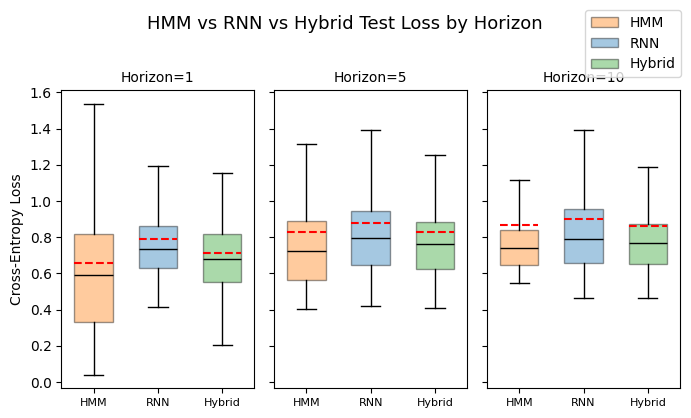

In [21]:
forecast_horizon = hmm_loss_test.shape[1]
fig, axes = plt.subplots(1, 3, figsize=(7, 4), sharey=True)

for i, h in enumerate([0, 4, 9]):
    ax = axes[i]
    bp_hmm = ax.boxplot(hmm_loss_test[:, h], positions=[0], widths=0.6,
                        patch_artist=True, showfliers=False,
                        showmeans=True, meanline=True,
                        boxprops=dict(facecolor='#ff7f0e', alpha=0.4),
                        medianprops=dict(color='black'),
                        meanprops=dict(color='red', linestyle='--', linewidth=1.5))

    bp_rnn = ax.boxplot(loss_test_h[:, h], positions=[1], widths=0.6,
                        patch_artist=True, showfliers=False,
                        showmeans=True, meanline=True,
                        boxprops=dict(facecolor='#1f77b4', alpha=0.4),
                        medianprops=dict(color='black'),
                        meanprops=dict(color='red', linestyle='--', linewidth=1.5))
    
    bp_hybrid = ax.boxplot(hybrid_loss[:, h], positions=[2], widths=0.6,
                        patch_artist=True, showfliers=False,
                        showmeans=True, meanline=True,
                        boxprops=dict(facecolor='#2ca02c', alpha=0.4),
                        medianprops=dict(color='black'),
                        meanprops=dict(color='red', linestyle='--', linewidth=1.5))

    ax.set_title(f'Horizon={h+1}', fontsize=10)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['HMM', 'RNN', 'Hybrid'], fontsize=8)
    if h == 0:
        ax.set_ylabel('Cross-Entropy Loss')

fig.legend([bp_hmm['boxes'][0], bp_rnn['boxes'][0], bp_hybrid['boxes'][0]], ['HMM', 'RNN', 'Hybrid'],
           loc='upper right', bbox_to_anchor=(0.99, 1.05))
fig.suptitle('HMM vs RNN vs Hybrid Test Loss by Horizon', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [43]:
# Build per-horizon loss summary table (Test set)
loss_mats = {
    "HMM": hmm_loss_test,
    "EDL": loss_test_h[:, :, 0],
    "Hybrid": hybrid_loss,
}

stats_per_model = []
for model_name, mat in loss_mats.items():
    q = np.quantile(mat, [0, 0.25, 0.50, 0.75, 1.00], axis=0)
    df_model = pd.DataFrame({
        "forecast_horizon": np.arange(1, mat.shape[1] + 1),
        "mean": mat.mean(axis=0),
        "min": q[0],
        "median": q[2],
        "max": q[4],
    })
    df_model["model"] = model_name
    stats_per_model.append(df_model)

summary_long = pd.concat(stats_per_model, ignore_index=True)

metric_order = ["max", "mean", "median", "min"]

summary_table = (
    summary_long
    .melt(
        id_vars=["model", "forecast_horizon"],
        value_vars=metric_order,
        var_name="metric",
        value_name="value",
    )
    .pivot_table(
        index=["metric", "model"],
        columns="forecast_horizon",
        values="value",
        aggfunc="first",
    )
    .reindex(metric_order, level="metric")
    .round(4)
)

print(summary_table)

forecast_horizon      1       2       3       4       5       6       7   \
metric model                                                               
max    EDL        2.3796  2.5899  2.8134  2.8445  2.8610  2.8635  2.8590   
       HMM        5.6254  5.5298  5.6158  5.1988  4.8714  4.6078  4.3835   
       Hybrid     2.9192  2.8351  2.8134  2.8445  2.8610  2.8635  2.8590   
mean   EDL        0.7898  0.8219  0.8474  0.8648  0.8791  0.8837  0.8916   
       HMM        0.6575  0.7275  0.7752  0.8071  0.8297  0.8432  0.8530   
       Hybrid     0.7152  0.7613  0.7901  0.8118  0.8285  0.8392  0.8476   
median EDL        0.7368  0.7502  0.7614  0.7742  0.7932  0.7900  0.7898   
       HMM        0.5924  0.6440  0.6944  0.7121  0.7230  0.7263  0.7297   
       Hybrid     0.6780  0.7166  0.7428  0.7504  0.7605  0.7617  0.7603   
min    EDL        0.4120  0.4311  0.4190  0.4193  0.4187  0.4300  0.4349   
       HMM        0.0399  0.0830  0.1248  0.1703  0.4018  0.4406  0.4726   
       Hybri

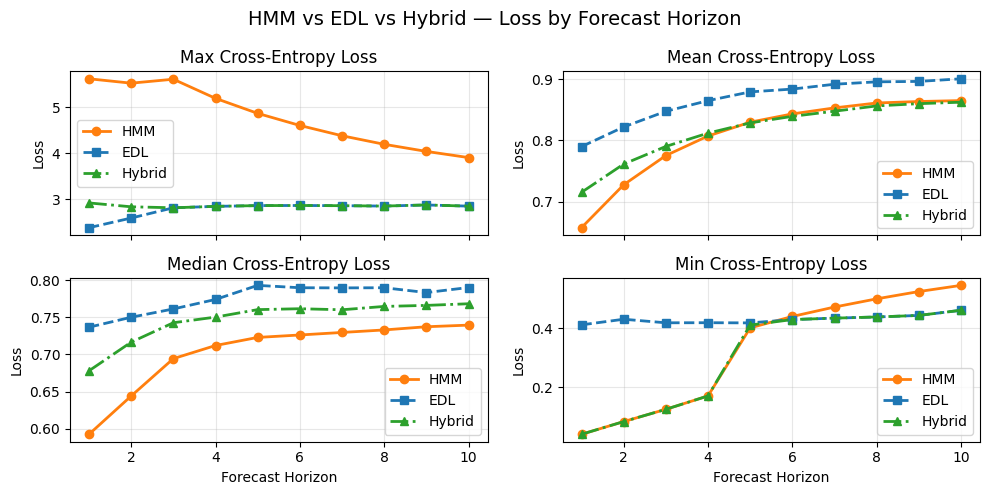

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True)

metrics = ["max", "mean", "median", "min"]
model_styles = {
    "HMM":    {"color": "#ff7f0e", "linestyle": "-",  "marker": "o"},
    "EDL":    {"color": "#1f77b4", "linestyle": "--", "marker": "s"},
    "Hybrid": {"color": "#2ca02c", "linestyle": "-.", "marker": "^"},
}

horizons = summary_table.columns.tolist()

for ax, metric in zip(axes.flat, metrics):
    for model_name, style in model_styles.items():
        values = summary_table.loc[(metric, model_name)]
        ax.plot(horizons, values,
                label=model_name,
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=2, markersize=6)
    ax.set_title(f"{metric.capitalize()} Cross-Entropy Loss", fontsize=12)
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[1]:
    ax.set_xlabel("Forecast Horizon")

plt.suptitle("HMM vs EDL vs Hybrid — Loss by Forecast Horizon", fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2759123/140742064.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


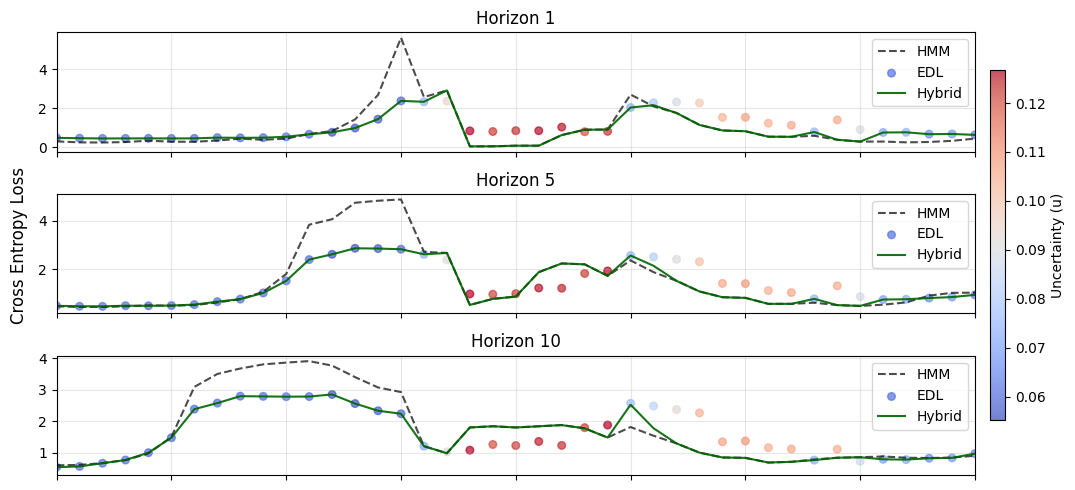

In [51]:
plt.figure(figsize=(10, 5))

horizons = [0, 4, 9]
titles = ['Horizon 1', 'Horizon 5', 'Horizon 10']
xlimits = [0, 40]

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_loss_test[:, horizon], label='HMM', color='black', linestyle='--', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test_h[:, horizon, 0])),
        y=loss_test_h[:, horizon, 0],
        c=(u_test_h[:, horizon, 0]),   # color by S_reshaped values
        cmap='coolwarm',  # blue=low S, red=high S
        alpha=0.7,
        s=30,
        label='EDL'
    )
    #plt.colorbar(sc, ax=ax, label='Confidence (S)')
    ax.plot(hybrid_loss[:, horizon], label='Hybrid', color='darkgreen', alpha=0.9)
    ax.set_title(titles[i])
    if i == 0:
        plt.gcf().supylabel('Cross Entropy Loss')
    ax.set_yscale('linear')
    ax.set_xticklabels([])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlimits[0], xlimits[1])
    # #ax.set_ylim(0, 6)
    # if i == len(horizons) - 1:
    #     tick_idx = np.arange(0, min(len(date_list), xlimits[1] + 1), 10)
    #     ax.set_xticks(tick_idx)
    #     ax.set_xticklabels([date_list[k].strftime("%Y-%m-%d") for k in tick_idx], rotation=0, ha='center')

fig = plt.gcf()
fig.subplots_adjust(right=0.88)  # leave room for colorbar on the right

if 'sc' in locals():
    cax = fig.add_axes([1, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(sc, cax=cax, label='Uncertainty (u)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2810339/893925296.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


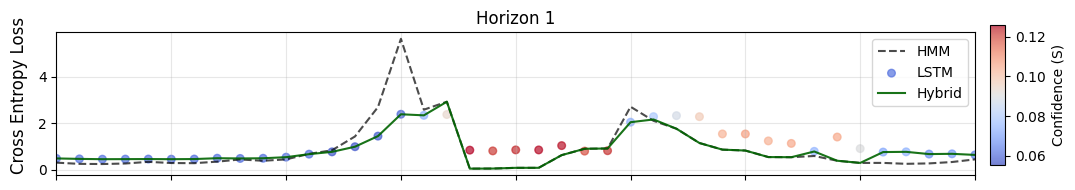

In [53]:
plt.figure(figsize=(10, 2))

horizons = [0]
titles = ['Horizon 1', 'Horizon 5', 'Horizon 10']
xlimits = [0, 40]

for i, horizon in enumerate(horizons):
    ax = plt.subplot(len(horizons), 1, i + 1)
    ax.plot(hmm_loss_test[:, horizon], label='HMM', color='black', linestyle='--', alpha=0.7)
    sc = ax.scatter(
        x=range(len(loss_test_h[:, horizon, 0])),
        y=loss_test_h[:, horizon, 0],
        c=(u_test_h[:, horizon, 0]),   # color by S_reshaped values
        cmap='coolwarm',  # blue=low S, red=high S
        alpha=0.7,
        s=30,
        label='LSTM'
    )
    #plt.colorbar(sc, ax=ax, label='Confidence (S)')
    ax.plot(hybrid_loss[:, horizon], label='Hybrid', color='darkgreen', alpha=0.9)
    ax.set_title(titles[i])
    if i == 0:
        plt.gcf().supylabel('Cross Entropy Loss')
    ax.set_yscale('linear')
    ax.set_xticklabels([])
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlimits[0], xlimits[1])
    # #ax.set_ylim(0, 6)
    # if i == len(horizons) - 1:
    #     tick_idx = np.arange(0, min(len(date_list), xlimits[1] + 1), 10)
    #     ax.set_xticks(tick_idx)
    #     ax.set_xticklabels([date_list[k].strftime("%Y-%m-%d") for k in tick_idx], rotation=0, ha='center')

fig = plt.gcf()
fig.subplots_adjust(right=0.88)  # leave room for colorbar on the right

if 'sc' in locals():
    cax = fig.add_axes([1, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
    fig.colorbar(sc, cax=cax, label='Confidence (S)')
plt.tight_layout()
plt.show()